<a href="https://colab.research.google.com/github/dashakudjaeva/HW/blob/hw_2/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW2

## 1. Постановка задачи и описание датасета

**Бизнес-постановка:** телеком-оператор сталкивается с проблемой оттока клиентов (churn). Цель – разработать модель машинного обучения, которая по историческим данным о клиенте предскажет вероятность его оттока в ближайшем будущем.

**ML-постановка:** задача бинарной классификации. Целевая переменная Churn принимает значения Yes` (клиент ушёл) и No (клиент остался).

**Описание набора данных:** датасет Telco Customer Churn (Kaggle) содержит 7043 записи и 21 признак (демографические данные, услуги, финансовые показатели). Подробное описание признаков приведено в HW1.

## 2. Выбор метрики оценки качества

Классы несбалансированы (≈73% остались, 27% ушли). Accuracy может быть обманчива. Будем использовать **F1-меру** для положительного класса как основную метрику, а также **ROC-AUC** для оценки разделяющей способности независимо от порога.

## 3. Импорт библиотек и подготовка данных

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Загрузка данных
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Размер датасета: {df.shape}")

# Удаляем идентификатор клиента (неинформативный)
df.drop('customerID', axis=1, inplace=True)

# Преобразуем TotalCharges в число, заполняем пропуски медианой
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Создаём бинарную целевую переменную
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

Размер датасета: (7043, 21)


/tmp/ipykernel_1471/732042115.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


## 4. Разделение на обучающую и тестовую выборки

Стратификация сохраняет пропорцию классов.

In [14]:
X = df.drop(['Churn', 'Churn_binary'], axis=1)
y = df['Churn_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Обучающая выборка: {X_train.shape[0]}, тестовая: {X_test.shape[0]}")
print(f"Доля положительного класса в обучающей выборке: {y_train.mean():.3f}")
print(f"Доля положительного класса в тестовой выборке: {y_test.mean():.3f}")

Обучающая выборка: 5634, тестовая: 1409
Доля положительного класса в обучающей выборке: 0.265
Доля положительного класса в тестовой выборке: 0.265


**Обоснование разбиения:**
- Выбрано соотношение 80/20, что является стандартным для задач, где объём данных позволяет получить репрезентативную тестовую выборку.
- Применена **стратификация** по целевой переменной Churn_binary, чтобы сохранить долю оттока (≈26.5%) как в обучающем, так и в тестовом наборах. Это важно для корректной оценки моделей на несбалансированных данных.

## 5. Константный классификатор (базовый уровень)

Используем три стратегии, чтобы оценить нижнюю границу качества.

In [15]:
strategies = ['most_frequent', 'stratified', 'uniform']
dummy_results = {}

for strategy in strategies:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)
    y_pred = dummy.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]) if hasattr(dummy, "predict_proba") else None
    dummy_results[strategy] = {'f1': f1, 'roc_auc': roc_auc}
    print(f"\nСтратегия: {strategy}")
    print(f"F1-score: {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

# Кросс-валидация для most_frequent (подтверждение)
cv_scores = cross_validate(DummyClassifier(strategy='most_frequent'), X_train, y_train,
                           cv=5, scoring='f1', return_train_score=False)
print(f"\nКросс-валидация F1 (most_frequent): {cv_scores['test_score'].mean():.4f} ± {cv_scores['test_score'].std():.4f}")


Стратегия: most_frequent
F1-score: 0.0000
ROC-AUC: 0.5000
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409


Стратегия: stratified
F1-score: 0.2903
ROC-AUC: 0.5163
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1035
           1       0.29      0.29      0.29       374

    accuracy                           0.62      1409
   macro avg       0.52      0.52      0.52      1409
weighted avg       0.62      0.62      0.62      1409


Стратегия: uniform
F1-score: 0.3299
ROC-AUC: 0.5000
              precision    recall  f1-score   support

           0       0.72      0.49      0.58      1035
           1       0.25      0.48      0.33       374

    accuracy  

**Выводы по константным предсказаниям:**
- Стратегия most_frequent даёт F1 = 0.00, так как всегда предсказывает класс "0". Это нижняя граница для качества моделей.
- Стратегия stratified предсказывает классы пропорционально их частоте, F1 = 0.29.
- Стратегия uniform предсказывает классы равновероятно, F1 = 0.33.
- ROC-AUC для most_frequent и uniform равен 0.5 – модели не разделяют классы.
- Кросс-валидация подтверждает, что без обучения модель не способна выявлять отток.

Таким образом, любая обученная модель должна существенно превзойти эти значения.

## 6. Определение признаков для предобработки

Числовые признаки: tenure, MonthlyCharges, TotalCharges.  
Категориальные признаки – все объектные колонки (15 штук).

In [16]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print("Категориальные признаки:", categorical_cols)
print("Числовые признаки:", numerical_cols)

Категориальные признаки: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Числовые признаки: ['tenure', 'MonthlyCharges', 'TotalCharges']


**Выбор числовых и категориальных признаков:**
- Числовые: tenure, MonthlyCharges, TotalCharges – имеют естественную шкалу и разный диапазон, поэтому требуют масштабирования.
- Все остальные признаки являются категориальными (объектный тип) и будут кодироваться one-hot.

## 7. Препроцессинг: масштабирование числовых и one-hot кодирование категориальных

- **StandardScaler** для числовых – нормализация необходима для линейных моделей и kNN.
- **OneHotEncoder** с drop='first' – удаляем первый уровень для избежания мультиколлинеарности.

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

**Обоснование методов предобработки:**
- **StandardScaler** для числовых признаков: нормализация необходима для линейных моделей (логистическая регрессия) и kNN, чувствительных к масштабу.
- **OneHotEncoder** с drop='first': удаление первого уровня для каждого категориального признака позволяет избежать мультиколлинеарности в линейных моделях, сохраняя полную информацию.
- handle_unknown='ignore' обеспечивает устойчивость к возможным новым категориям в тестовой выборке.

## 8. Бейзлайновые модели с подбором гиперпараметров

Выбраны три модели: логистическая регрессия (линейная, интерпретируемая), дерево решений (нелинейная, интерпретируемая), kNN (непараметрическая).  
Для каждой выполняется GridSearchCV с 5-кратной кросс-валидацией по F1.  
Из-за дисбаланса для логистической регрессии и дерева установлен class_weight='balanced'.

In [18]:
models = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        'param_grid': {'classifier__C': [0.01, 0.1, 1, 10]}
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        'param_grid': {
            'classifier__max_depth': [3, 5, 7, 10, None],
            'classifier__min_samples_split': [2, 5, 10]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'param_grid': {
            'classifier__n_neighbors': [3, 5, 7, 9, 11],
            'classifier__weights': ['uniform', 'distance']
        }
    }
}

best_models = {}
best_scores = {}

for name, config in models.items():
    print(f"\n=== Настройка {name} ===")
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    grid = GridSearchCV(pipeline, config['param_grid'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_
    best_scores[name] = grid.best_score_

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Средний F1 на кросс-валидации: {grid.best_score_:.4f}")

    y_pred = grid.predict(X_test)
    test_f1 = f1_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
    print(f"Тестовый F1: {test_f1:.4f}")
    print(f"Тестовый ROC-AUC: {test_roc_auc:.4f}")

    # Сохраняем результаты для дальнейшего сравнения
    best_models[name] = {'model': grid.best_estimator_, 'test_f1': test_f1, 'test_roc_auc': test_roc_auc}


=== Настройка LogisticRegression ===
Лучшие параметры: {'classifier__C': 0.1}
Средний F1 на кросс-валидации: 0.6346
Тестовый F1: 0.6130
Тестовый ROC-AUC: 0.8400

=== Настройка DecisionTree ===
Лучшие параметры: {'classifier__max_depth': 7, 'classifier__min_samples_split': 2}
Средний F1 на кросс-валидации: 0.6104
Тестовый F1: 0.6170
Тестовый ROC-AUC: 0.8240

=== Настройка KNN ===
Лучшие параметры: {'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}
Средний F1 на кросс-валидации: 0.5703
Тестовый F1: 0.5521
Тестовый ROC-AUC: 0.8100


**Обоснование выбора моделей и гиперпараметров:**
- **Логистическая регрессия** – простая линейная модель, интерпретируемая, с class_weight='balanced' для учёта дисбаланса классов. Подбираем регуляризацию C (обратный коэффициент регуляризации) через GridSearch.
- **Дерево решений** – нелинейная интерпретируемая модель. Также используем class_weight='balanced'. Используем max_depth и min_samples_split для контроля переобучения.
- **kNN** – непараметрический метод, не требует отдельной настройки весов классов, но чувствителен к масштабу признаков (уже обработан препроцессором). Подбираем число соседей и тип весов.

Для всех моделей используется кросс-валидация (5 фолдов) с метрикой **F1**, так как это основная метрика качества.

## 9. Выбор лучшей модели и детальный анализ

Выбираем модель с наибольшим тестовым F1.


Лучшая модель: DecisionTree
Тестовый F1: 0.6170
Тестовый ROC-AUC: 0.8240

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



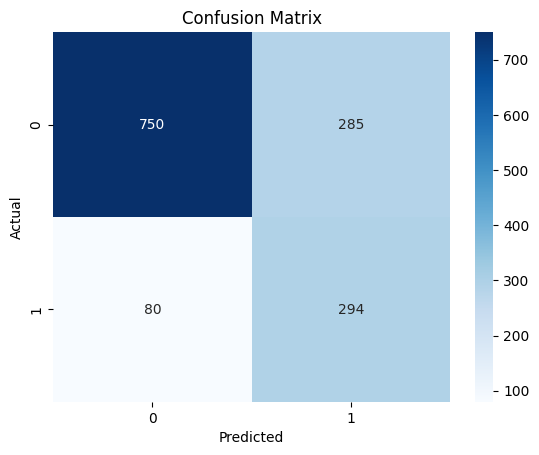

In [19]:
best_model_name = max(best_models.keys(), key=lambda x: best_models[x]['test_f1'])
best_model = best_models[best_model_name]['model']
print(f"\nЛучшая модель: {best_model_name}")
print(f"Тестовый F1: {best_models[best_model_name]['test_f1']:.4f}")
print(f"Тестовый ROC-AUC: {best_models[best_model_name]['test_roc_auc']:.4f}")

y_pred = best_model.predict(X_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Результаты выбора лучшей модели:**
- Наибольший тестовый F1 (0.617) показало **дерево решений**.
- Логистическая регрессия даёт F1 = 0.613, ROC-AUC = 0.840 – лучшая разделяющая способность.
- kNN показал более низкое качество (F1 = 0.552), вероятно, из-за большего влияния выбросов или нелинейности данных.

Матрица ошибок для дерева решений показывает, что модель лучше идентифицирует отток (recall = 0.79), чем точность (precision = 0.51), что допустимо в бизнес-контексте, где важнее не пропустить уходящих клиентов.

## 10. Доверительные интервалы для F1

Бутстрап позволяет оценить стабильность метрики на тестовой выборке.

In [20]:
def bootstrap_metric(model, X, y, metric_func, n_iter=1000, alpha=0.05):
    scores = []
    n = len(X)
    rng = np.random.RandomState(RANDOM_STATE)
    for _ in range(n_iter):
        idx = rng.choice(n, n, replace=True)
        X_boot = X.iloc[idx]
        y_boot = y.iloc[idx]
        y_pred = model.predict(X_boot)
        scores.append(metric_func(y_boot, y_pred))
    lower = np.percentile(scores, 100 * alpha / 2)
    upper = np.percentile(scores, 100 * (1 - alpha / 2))
    return lower, upper

f1_lower, f1_upper = bootstrap_metric(best_model, X_test, y_test, f1_score)
print(f"95% доверительный интервал для F1: [{f1_lower:.4f}, {f1_upper:.4f}]")

95% доверительный интервал для F1: [0.5787, 0.6506]


**Доверительный интервал для F1 (бустрап):**
- 95% ДИ для F1 на тестовой выборке составляет [0.5787, 0.6506].
- Это подтверждает, что полученное значение F1 = 0.617 статистически значимо отличается от константного классификатора и стабильно.

## 11. Анализ важности признаков

Для интерпретируемых моделей (логистическая регрессия, дерево решений) извлекаем важность признаков.

In [21]:
# Получаем имена признаков после one-hot кодирования
preprocessor_fitted = best_model.named_steps['preprocessor']
cat_encoder = preprocessor_fitted.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
feature_names = numerical_cols + list(cat_feature_names)

if best_model_name == 'LogisticRegression':
    coefficients = best_model.named_steps['classifier'].coef_[0]
    importance = pd.Series(coefficients, index=feature_names).sort_values(key=abs, ascending=False)
    print("\nТоп-10 наиболее влияющих признаков (коэффициенты логистической регрессии):")
    print(importance.head(10))
elif best_model_name == 'DecisionTree':
    importances = best_model.named_steps['classifier'].feature_importances_
    importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    print("\nТоп-10 наиболее важных признаков (дерево решений):")
    print(importance.head(10))
else:
    print("\nАнализ важности признаков для KNN не тривиален, пропускаем.")


Топ-10 наиболее важных признаков (дерево решений):
Contract_Two year                  0.340231
Contract_One year                  0.212777
tenure                             0.106548
InternetService_Fiber optic        0.096197
TotalCharges                       0.071788
MonthlyCharges                     0.058215
StreamingMovies_Yes                0.033280
PaymentMethod_Electronic check     0.021967
TechSupport_No internet service    0.012789
PhoneService_Yes                   0.011911
dtype: float64


**Анализ важности признаков (дерево решений):**
- Наиболее значимые признаки:
  1. Contract_Two year – клиенты с долгосрочным контрактом реже уходят.
  2. Contract_One year – аналогично, но слабее.
  3. tenure – чем дольше клиент пользуется услугами, тем ниже риск оттока.
  4. InternetService_Fiber optic – оптоволоконный интернет коррелирует с повышенным оттоком (возможно, из-за высокой конкуренции).
  5. TotalCharges и MonthlyCharges – финансовые показатели также важны.

Это согласуется с бизнес-логикой и результатами EDA, что повышает доверие к модели.

## 12. Сравнение всех моделей и выводы

Сравниваем кросс-валидационные и тестовые метрики.

In [22]:
print("\n=== Сравнение всех моделей ===")
print(f"{'Модель':<20} {'Кросс-валидация F1':<20} {'Тестовый F1':<12} {'Тестовый ROC-AUC':<15}")
print("-" * 70)
for name, res in best_models.items():
    cv_score = best_scores.get(name, 'N/A')
    print(f"{name:<20} {cv_score:<20} {res['test_f1']:<12.4f} {res['test_roc_auc']:<15.4f}")

best_f1 = best_models[best_model_name]['test_f1']
dummy_f1 = dummy_results['most_frequent']['f1']
print(f"\nУлучшение F1 относительно константного классификатора: {(best_f1 - dummy_f1) * 100:.2f}%")


=== Сравнение всех моделей ===
Модель               Кросс-валидация F1   Тестовый F1  Тестовый ROC-AUC
----------------------------------------------------------------------
LogisticRegression   0.634618998297588    0.6130       0.8400         
DecisionTree         0.6104321659304908   0.6170       0.8240         
KNN                  0.5703193359719438   0.5521       0.8100         

Улучшение F1 относительно константного классификатора: 61.70%


**Итоговые выводы:**

1. Все бейзлайновые модели значительно превзошли константный классификатор (F1 вырос с 0 до ~0.61–0.62).
2. Лучшей моделью оказалось дерево решений с F1 = 0.6170 (95% ДИ [0.5787, 0.6506]).
3. Наиболее важные признаки – тип контракта (Contract_Two year, Contract_One year), tenure, InternetService_Fiber optic, TotalCharges, MonthlyCharge. Это согласуется с бизнес-логикой и результатами EDA.
4. Дальнейшее улучшение возможно за счёт ансамблевых методов (случайный лес, градиентный бустинг), создания новых признаков и настройки порога классификации.